In [1]:
%%bash
mkdir storm_mode
cd storm_mode

wget -nc -q https://raw.githubusercontent.com/ahaberlie/unidata-workshop-2018/refs/heads/master/workshop/data/training/sample_train_data.csv
wget -nc -q https://raw.githubusercontent.com/ahaberlie/unidata-workshop-2018/refs/heads/master/workshop/data/training/sample_test_data.csv

# L8 - Ensemble Methods with Decision Trees

Directions:

1. Please rename the file by clicking on “LX-First-Last.ipynb” where X is the lab number, and replace First and Last with your first and last name.

2. Click File -> Save to make sure your most recent edits are saved.

3. In the upper right hand corner of the screen, click on “Share”. Click on “Restricted” and change it to “Anyone with the link”. Make sure you also share it with `ahaberlie1@gmail.com`.

4. Copy the link and submit it on Blackboard. Make sure you follow these steps completely, or I will be unable to grade your work.

### Overview

This lab will help you understand scikit-learn and its ensemble model capabilities. We will walk through some examples of how scikit-learn can help solve Geoscience problems. Periodically, I will 1) ask you to either repeat the demonstrated code in a slightly different way; or 2) ask you to combine two or more techniques to solve a problem.

You can use generative AI to help answer these problems. **The answer should still be in your own words.** Think of the generative AI descriptions as those from a book. You still have to cite your source and you cannot plagiarize directly from the source. For every question that you used generative AI for help, please reference the generative AI you used and what your prompt or prompts were.

However, it is crucial that you understand the code well enough to effectively use generative AI tools that are likely to be widely available and recommended for use at many organizations. Although they are improving at an incredible rate, they still produce bugs, especially with domain-specific and complex problems. Make sure that you verify the answers before putting them in your own words.

**Model performance assessment**

When assessing model performance, we typically separate the sample data into three subsets. Think of your own experiences preparing for an exam as motivation for the subsets:

1. Training data - this is what the machine learning approach uses to generate a model. Similar to lectures/homework/assignments/etc. in class.
2. Validation data - this is what is used to do quick "spot checks" on the model and help determine optimal model settings. This is similar to doing a practice quiz and learning what you need to focus on before the exam.
3. Testing data - this is what is used to test the performance of the model. This is similar to finally taking the exam.

I have provided you with the training and testing datasets. We will also generate the validation dataset below:

In [2]:
import pandas as pd
import numpy as np

np.random.seed(4)

def custom_train_split(df, val_year_start=2012):
    '''Takes a pandas DataFrame with training data
    and sorts it into two subsets: 1) training data before
    and including `val_year_start`; and 2) validation data
    after `val_year_start`

    Parameters:
        df: pandas DataFrame
            Original training data.
        val_year_start: int
            Year that defines the split between training and
            validation data. Default 2011. Must be between
            2006 and 2012.

    Returns:
        (df_train, df_test): tuple
            DataFrames split into training and testing data
    '''
    df_train = df[df['datetime'].dt.year < val_year_start]
    df_val = df[df['datetime'].dt.year >= val_year_start]

    return df_train, df_val

def convert_to_numpy(df, remove_cols=None, binary_label='MCS',
                     label_col='label_name'):
    '''Converts DataFrame to machine learning friendly
    format by removing non-numeric columns and columns
    provided by `remove_cols`.

    Parameters:
        df: pandas DataFrame
            Original DataFrame with all columns
        remove_cols: list
            Other columns to remove that are numeric.
        binary_label: str
            If not None, convert label to 1 if `label_cols`
            is equal to `binary_label` in `df`.
        label_col: str
            Column name in `df` that contains original labels.

    Returns:
        npy_data: numpy ndarray
            Converted data ready for the training process.
    '''
    df_ = df.copy()

    if remove_cols is None:
        remove_cols = ['index', 'label', 'label1']

    numeric_cols = df_.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in remove_cols]

    if binary_label is not None:
        df_[binary_label] = df_[label_col] == binary_label

    df_x = df_[numeric_cols].to_numpy()
    df_y = df_[binary_label].to_numpy()

    return df_x, df_y, numeric_cols

df_train = pd.read_csv("storm_mode/sample_train_data.csv")
df_test = pd.read_csv("storm_mode/sample_test_data.csv")

df_train['datetime'] = pd.to_datetime(df_train['datetime'])
df_train = df_train.sort_values(by='datetime')
df_test['datetime'] = pd.to_datetime(df_test['datetime'])

df_train, df_val = custom_train_split(df_train)

## Problem 1

A pandas `DataFrame` has a method called `sample` that will randomly sample the dataset (with or without replacement) and set it equal to a variable. As we discussed with Random Forest, this is one of the foundational aspects of bootstrapping.

In a random forest with 50 estimators, each tree is trained on its own bootstrapped version of the training data. That means we generate 50 resampled datasets, calculate the feature means for each one, and then plot the distribution of those means to show how sampling variability creates diversity across trees. We will standardize the values to identify outliers.

The size of each bootstrapped sample is the same as the original dataset. The difference is some rows are repeated. You can see the repeated rows as a percentage of total rows reported below.

In the textbox below labeled "Answer" for this problem:

### Problem 1a

Follow these steps and answer where prompted:

Slowly increase the number of `n_bootstrap` from 1 - 50. discuss what you notice about the z-scores for each variable. What does this tell you about the datasets that each Decision Tree within the Random Forest will see and use for training?

Answer:

Mean % of repeats per bootstrap = 36.57%


Text(0.5, 1.0, 'Distribution of Mean Values per Bootstrap')

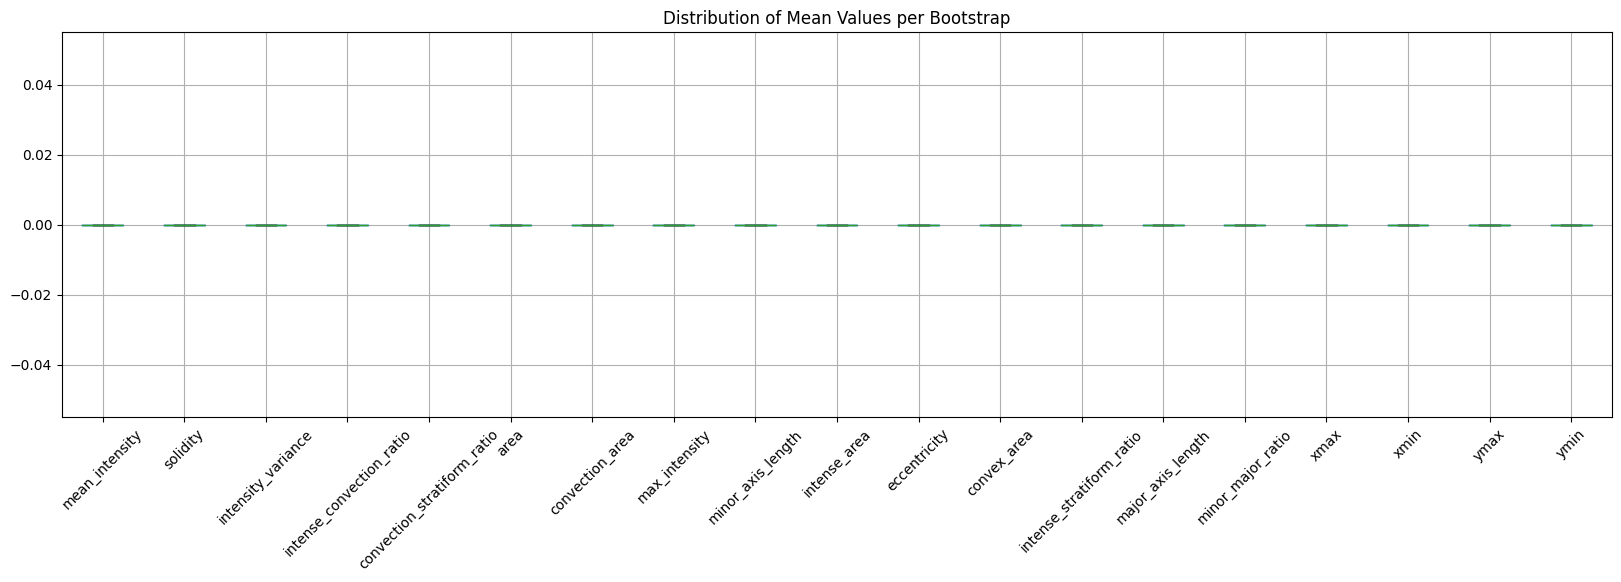

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = 20, 5

from sklearn.preprocessing import StandardScaler
import pandas as pd

n_bootstraps = 1

_, _, num_cols = convert_to_numpy(df_train)

bootstrap_means = []

repeat_list = []

for i in range(n_bootstraps):
    train_sub = df_train.sample(n=len(df_train), replace=True, random_state=i)
    repeats = train_sub.index.duplicated()
    repeat_list.append(np.sum(repeats))

    bootstrap_means.append(train_sub[num_cols].mean())

print(f"Mean % of repeats per bootstrap = {100 * np.mean(repeat_list) / len(df_train):.2f}%")
bootstrap_means_df = pd.DataFrame(bootstrap_means)

scaler = StandardScaler().set_output(transform="pandas")

bootstrap_z = scaler.fit_transform(bootstrap_means_df)

ax = bootstrap_z.boxplot(rot=45)

ax.set_title("Distribution of Mean Values per Bootstrap")

Random Forest also chooses a random subset of available features to make available for split decisions. The number of features it picks in `sklearn` is the square root of the total number of features.

Using the [`sample` documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html), modify the code below to provide a random subset of `sqrt_n` *columns* and set it equal to the variable `df_random_features`.

### Problem 1b

Follow these steps and answer where prompted:

1. `sqrt_n`: equal to the square root of the length of `num_cols` rounded up to the nearest `int`.

2. `df_random_features`: in one line, use the `pandas` `sample` function to get a random subset of features (i.e., columns) from `df_train[num_cols]`.

3. Run the code a few times and answer below: What happened to the DataFrame? How is it different from the original `df_train[num_cols]`?

Answer for #3:

In [4]:
sqrt_n = 1

df_random_features = df_train[num_cols]

display(df_random_features)

,mean_intensity,solidity,intensity_variance,intense_convection_ratio,convection_stratiform_ratio,area,convection_area,max_intensity,minor_axis_length,intense_area,eccentricity,convex_area,intense_stratiform_ratio,major_axis_length,minor_major_ratio,xmax,xmin,ymax,ymin
244,25.730325,0.354756,31.034442,0.012522,0.027516,336672,9264,55,561.770924,116,0.913296,949024,0.000345,1379.269495,0.407296,3391,2631,790,347
293,24.587115,0.470852,20.780496,0.016690,0.007862,365816,2876,50,454.243000,48,0.956578,776924,0.000131,1558.414095,0.291478,3439,2589,650,304
17,30.727989,0.541433,59.903655,0.122665,0.195170,75688,14772,60,223.941478,1812,0.918075,139792,0.023940,564.928958,0.396406,2641,2320,956,782
50,31.076728,0.460556,69.420183,0.213526,0.203976,295172,60208,65,462.588463,12856,0.951475,640904,0.043554,1503.243456,0.307727,1965,1444,1058,389
64,31.591241,0.498818,63.600245,0.189928,0.210805,309708,65288,65,454.336266,12400,0.956694,620884,0.040038,1560.782308,0.291095,1993,1477,1058,376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,23.093333,0.571066,8.520178,0.000000,0.000000,4500,0,30,60.216957,0,0.833472,7880,0.000000,108.977652,0.552562,1552,1490,280,236
383,23.282887,0.278806,9.595179,0.000000,0.000000,3436,0,35,75.322799,0,0.782560,12324,0.000000,120.985839,0.622575,1537,1463,294,242
384,20.594233,0.515965,2.934510,0.000000,0.000000,5688,0,30,87.946377,0,0.739717,11024,0.000000,130.694123,0.672918,2445,2372,782,731
390,21.181102,0.593458,4.510509,0.000000,0.000000,3048,0,25,56.200869,0,0.813932,5136,0.000000,96.737798,0.580961,2435,2387,772,735


### Problem 2

A bootstrapped version of the dataset is provided to each Decision Tree in a Random Forest. Additional variance is introduced when features are randomly selected at *each split decision*. This second step can be pretty difficult code manually, so we are going to utilize the built-in functionality of `DecisionTreeClassifier` to simulate how one Decision Tree in a Random Forest might be generated.

### Problem 2a

Follow these steps and answer where prompted:

1. Set `bootstrap` equal to a bootstrapped sample of `df_train` with replacement.

2. Modify the `train_x` and `train_y` function call `convert_to_numpy` so it converts the bootstrapped DataFrame to numpy, not `df_train`.

3. Set `n_sqrt` based on `num_cols` and the code you created in `1b`.

4. Create your `DecisionTreeClassifier` by adding the `max_features` parameter and setting it equal to `n_sqrt`.

5. Run the code multiple times. What do you notice about the plotted trees? Put your answer in the text box below:


Answer for #5

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
plt.rcParams['figure.figsize'] = 15, 10


bootstrap = df_train

train_x, train_y, num_cols = convert_to_numpy(df_train)

n_sqrt = 1

CART = DecisionTreeClassifier(max_features=1, max_depth=2)

CART.fit(train_x, train_y)

plot_tree(CART, feature_names=num_cols, class_names=['Not MCS', 'MCS']);


### Problem 4

Recall that Random Forest is not only a bootstrapping method, but also an aggregating method (i.e., "bagging"). We need to consider "votes" from many individual Decision Trees to arrive at the final prediction. We can simulate this by following the steps below:

Problem 4a:

1. create a variable named `n_estimators` and set it equal to `10` for now.

2. create a list that will store the trained decision trees called `random_trees`.

3. create a loop with `n_estimators` iterations

4. for each iteration, train a decision tree like you did in Problem 3. **Do not plot the tree!!! You have been warned!!!**

5. append the tree to the `random_tree` list.

Congratulations, you trained a Random Forest from scratch (kind of...).

In [6]:
n_estimators = 1

random_trees = []

for i in range(1):

    bootstrap = df_train.sample(n=len(df_train), replace=True, random_state=i)

    train_x, train_y, num_cols = convert_to_numpy(bootstrap)

    n_sqrt = 1

    CART = DecisionTreeClassifier(max_features=1, max_depth=2, random_state=i)

    CART.fit(train_x, train_y)

    random_trees.append(CART)

print(random_trees)




[DecisionTreeClassifier(max_depth=2, max_features=1, random_state=0)]


Problem 4b

Next, we need to create and aggregate predictions. We should do this on the validation subset. For this subset, **we do not bootstrap**. Bootstrapping should **only** be done on the training data. Using validation data to adjust our model is our attempt to assess the generalizability of the model on the testing dataset.

 We can demonstrate on one labeled validation sample.

1. convert `df_val` to numpy, by setting the `val_x` and `val_y` variables.

2. choose one random sample from `val_x` and `val_y` by randomly selecting an index between 0 and `len(val_y)`. We need this to extract the random sample from each numpy array.

3. create a list named `predictions` to store the votes.

4. loop through random_trees and make a prediction using `val_x`. Save the vote in `predictions`.

5. find the most common label and that is your prediction.

The output should look like this (will be different based on your chosen `idx`):

```
The actual answer is MCS
----------------------
The random tree ensemble votes:
----------------------
tree #0 votes for Not MCS
tree #1 votes for Not MCS
tree #2 votes for MCS
***many rows removed for space just in this markdown. These should be included in your output below***
tree #48 votes for MCS
tree #49 votes for Not MCS
----------------------
The predicted label is MCS. 64.00% of trees agreed.
```

6. Run the predictions for different values of `idx`. Can you find any cases where the confidence of the model was low (e.g., max probability < 80%)? When the confidence was low, what did the votes look like in your ensemble? How would you explain to "Grandma Goody" what the probability means for the ensemble?

7. Pick an `idx` below and fill out the following. If you see something like `P(Not MCS)`, that is equivalent to the confidence of the ensemble:

- Actual label:
- Predicted label:
- P(Not MCS)
- P(MCS)

Next, change `n_estimators` to `100` in Problem 4, rerun it, and then run the code below. Fill in the new values:

- Actual label:
- Predicted label:
- P(Not MCS)
- P(MCS)
    
Did the prediction change? Did the confidence change? What did you notice about the run with `10` predictors and the one with `100` predictors? Answer below:

Answer:

In [7]:
import numpy as np

val_x, val_y, num_cols = convert_to_numpy(df_train)

idx = 0
sample_x, sample_y = val_x[idx], val_y[idx]

label_convert = {0: "Not MCS", 1: "MCS"}

predictions = []

for tree in random_trees:
    vote = tree.predict([sample_x])[0]
    predictions.append(1)

predictions = np.array(predictions)

print(f"The actual answer for index {idx} is {label_convert[int(sample_y)]}")
print("----------------------")
print("The random tree ensemble votes for:")
print("----------------------")

for i, vote in enumerate(predictions):
    print(f"tree #{i} votes for {label_convert[int(vote)]}")

num_trees = len(random_trees)

# how many == 1?
yes_count = 1

# how many == 0?
no_count = 1

# what fraction == 1?
yes_frac = 1

# what fraction == 0?
no_frac = 1

combined_p = [no_frac, yes_frac]
max_label = np.argmax(combined_p)
p_agree = 100 * np.max(combined_p)

print("----------------------")
print(f"Predicted label: {label_convert[max_label]}")
print(f"{p_agree:.2f}% of trees agreed.")
print(f"P(Not MCS) = {100*no_frac:.2f}%")
print(f"P(MCS)     = {100*yes_frac:.2f}%")

The actual answer for index 0 is Not MCS
----------------------
The random tree ensemble votes for:
----------------------
tree #0 votes for MCS
----------------------
Predicted label: Not MCS
100.00% of trees agreed.
P(Not MCS) = 100.00%
P(MCS)     = 100.00%


### Problem 5

Based on how we have evaluated models in the past, evaluate the performance of your model at `10` and `100` estimators in the code block below using the testing dataset: